In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

FIG_SIZE = (10, 8)
SIZE = 22
SIZE_SMALL = 18
FONT_SIZE = int(SIZE)
FONT_SIZE_SMALL = int(SIZE_SMALL)
FONT_WEIGHT = "bold"
MARKER_SIZE = 10
LINE_WIDTH = 2
GRID = True
ERRORBAR = ("ci", 95)

PLOT_DPI = 600
PLOT_FORMAT = "pdf"
PLOT_DIR = Path("../plots")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

rc = {
    "figure.figsize": FIG_SIZE,
    "figure.titlesize": 20,
    "axes.labelsize": FONT_SIZE,
    "axes.labelweight": FONT_WEIGHT,
    "legend.fontsize": FONT_SIZE_SMALL,
    "legend.title_fontsize": FONT_SIZE_SMALL,
    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,
    "lines.markersize": MARKER_SIZE,
    "lines.linewidth": LINE_WIDTH,
    "axes.titlesize": FONT_SIZE_SMALL,
    "axes.grid": GRID,
}

sns.set_theme(style="whitegrid", palette="colorblind", context="paper", rc=rc)

In [2]:
from pathlib import Path

import pandas as pd

# Load the data
df_path = Path("../parquets/clean-sci-aware.parquet")
df = pd.read_parquet(df_path)
df["size"] = pd.to_numeric(df["size"], errors="coerce")
df["time"] = pd.to_numeric(df["time"], errors="coerce")
df["sci"] = pd.to_numeric(df["sci"], errors="coerce")

NODES = [int(i) for i in sorted(df["size"].unique())]
APPLICATIONS = sorted(df["application"].unique())
for application in APPLICATIONS:
    Path(PLOT_DIR / application).mkdir(parents=True, exist_ok=True)

MODES = sorted(df["mode"].unique())

In [3]:
df_success = df[(df["success"] == True) & (~df["heuristic"].isin(["exhaustive"]))]
df_failed = df[(df["success"] == False) & (~df["heuristic"].isin(["exhaustive"]))]

In [4]:
def plot_execution_time(df: pd.DataFrame, application="demo", mode="random"):
    df = df[(df["application"] == application) & (df["mode"] == mode)].copy()
    plt.figure(figsize=FIG_SIZE)
    sns.lineplot(
        data=df,
        x="size",
        y="time",
        hue="heuristic",
        style="heuristic",
        errorbar=ERRORBAR,
    )
    plt.title(f"Execution Time - {application} ({mode})")
    plt.xscale("log", base=2)
    plt.xlabel("Number of Nodes")
    plt.ylabel("Execution Time (s)")

    plt.tight_layout()
    # plt.show()
    plt.savefig(PLOT_DIR / application / f"{mode}-time.pdf", format=PLOT_FORMAT, dpi=PLOT_DPI)

In [5]:
def plot_sci(df: pd.DataFrame, application="demo", mode="random"):
    df = df[(df["application"] == application) & (df["mode"] == mode)].copy()
    plt.figure(figsize=FIG_SIZE)
    sns.lineplot(
        data=df,
        x="size",
        y="sci",
        hue="heuristic",
        style="heuristic",
        errorbar=ERRORBAR,
    )
    plt.title(f"SCI - {application} ({mode})")
    plt.xscale("log", base=2)
    plt.xlabel("Number of Nodes")
    plt.ylabel("SCI")

    plt.tight_layout()
    # plt.show()
    plt.savefig(PLOT_DIR / application / f"{mode}-sci.pdf", format=PLOT_FORMAT, dpi=PLOT_DPI)

In [6]:
def plot_relative_sci_distance(df: pd.DataFrame, application="demo"):
    df = df[
        (df["mode"] == "curated")
        & (df["success"] == True)
        & (df["application"] == application)
    ].copy()

    
    # SCI exhaustive
    exhaustive = df[df["heuristic"] == "exhaustive"][
        ["application", "seed", "size", "sci"]
    ].rename(columns={"sci": "sci_exhaustive"})

    # merge for the baseline
    df = df.merge(
        exhaustive,
        on=["application", "seed", "size"],
        how="left",
    )

    # relative distance from exhaustive
    df["sci_distance_pct"] = (
        (df["sci"] - df["sci_exhaustive"]) / df["sci_exhaustive"]
    ) * 100

    # remove exhaustive from the plot (always 0% distance)
    df = df[df["heuristic"] != "exhaustive"]
    
    plt.figure(figsize=FIG_SIZE)

    sns.lineplot(
        data=df,
        x="size",
        y="sci_distance_pct",
        hue="heuristic",
        style="heuristic",
        errorbar=ERRORBAR,
    )

    plt.ylabel("SCI distance from exhaustive (%)")
    plt.xlabel("Infrastructure size")
    plt.xscale("log", base=2)
    plt.title(f"Relative SCI distance from exhaustive - {application}")

    plt.tight_layout()
    # plt.show()
    plt.savefig(PLOT_DIR / application / f"sci-distance.pdf", format=PLOT_FORMAT, dpi=PLOT_DPI)

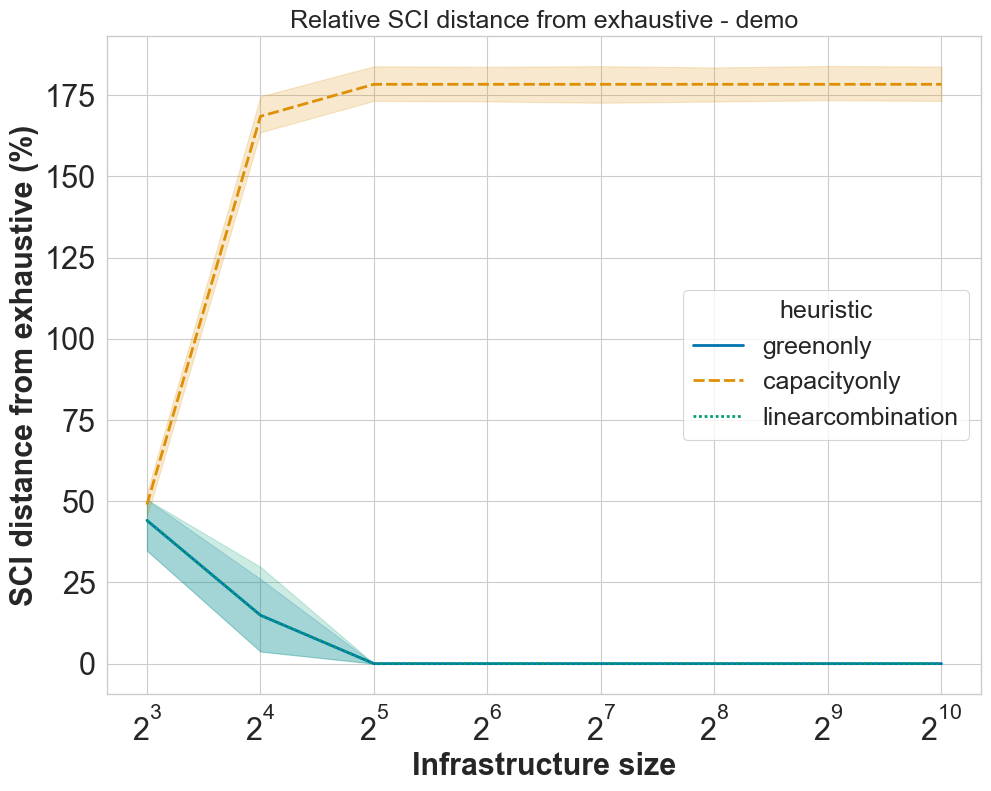

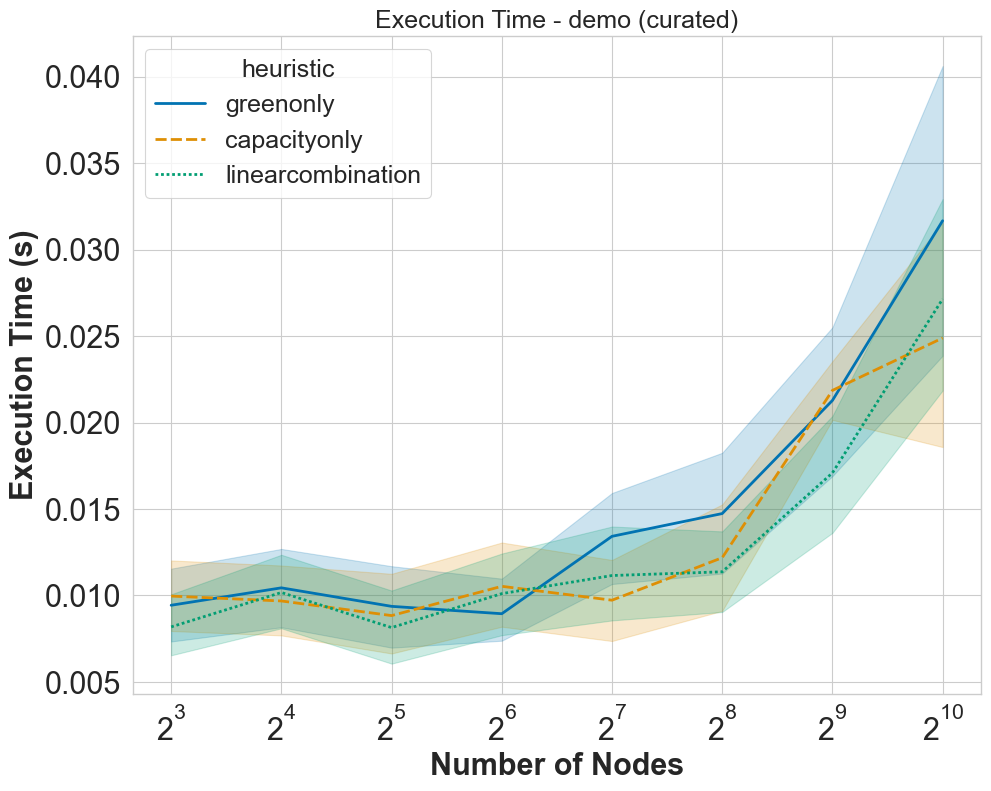

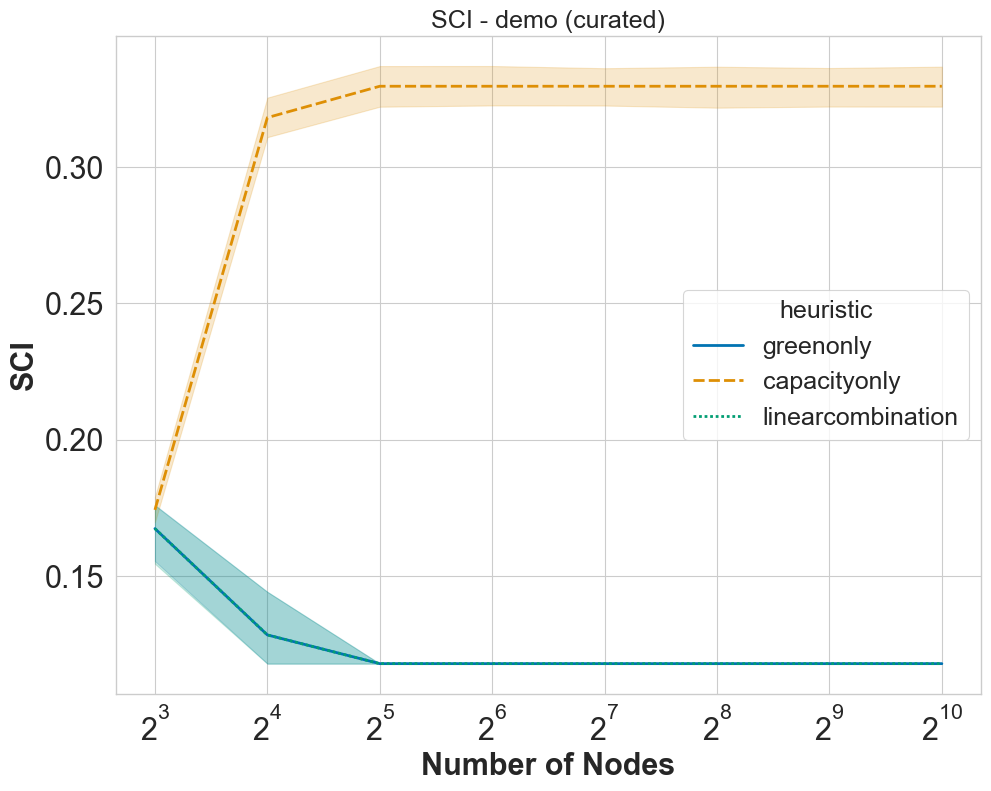

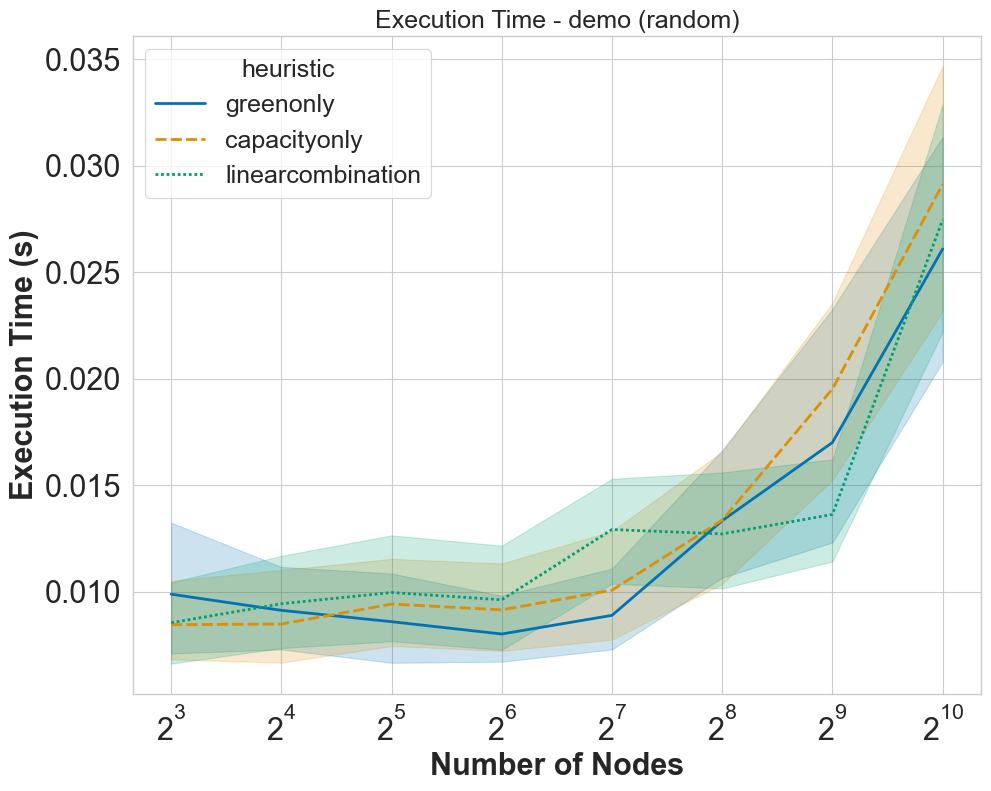

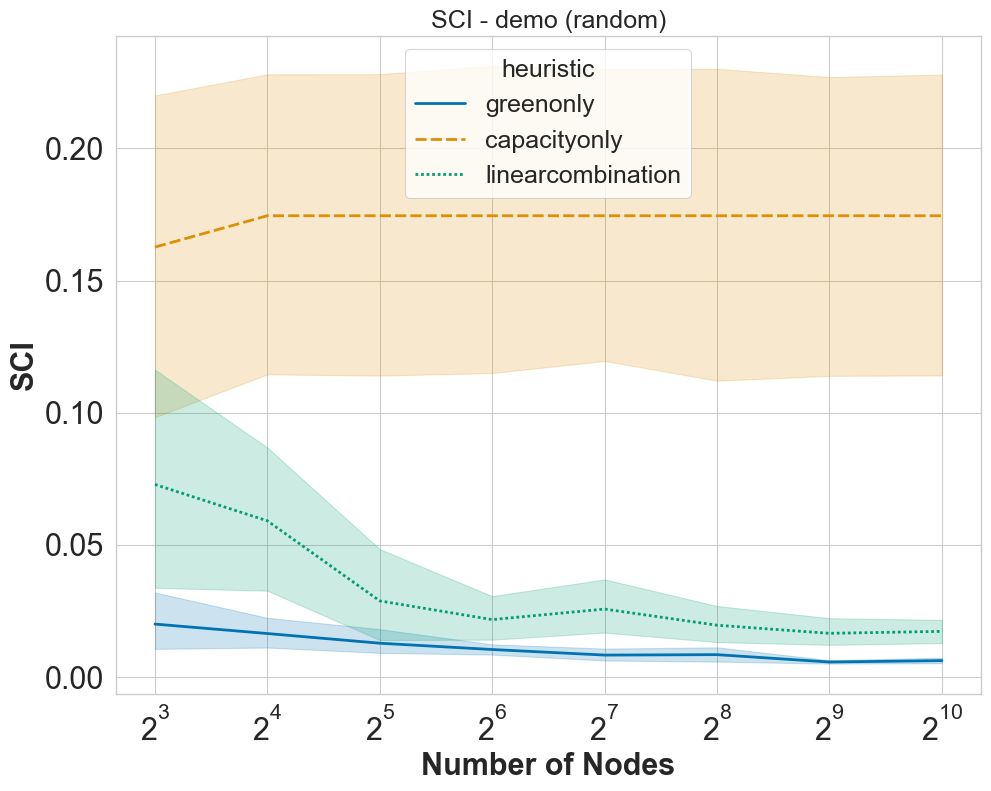

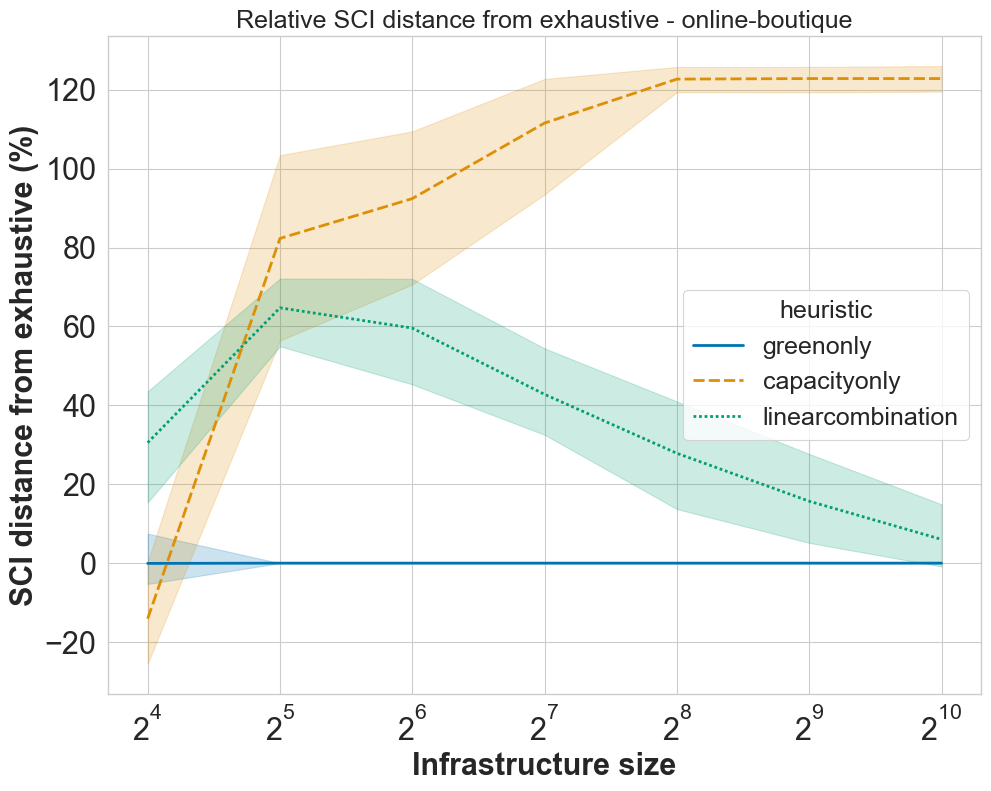

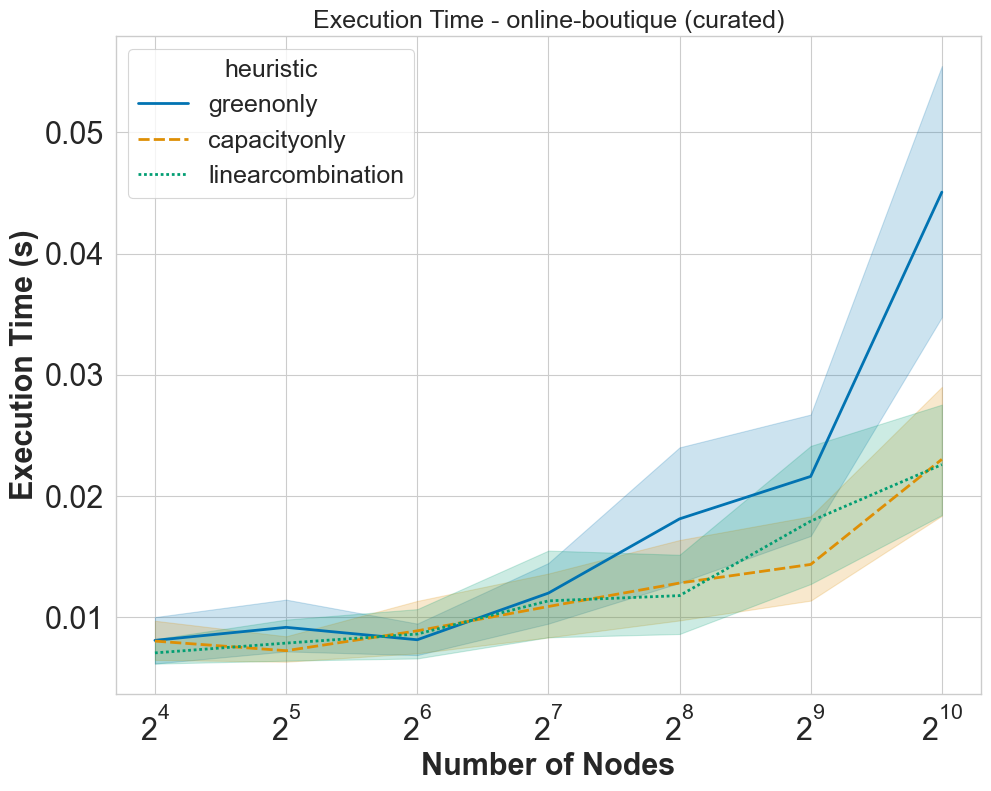

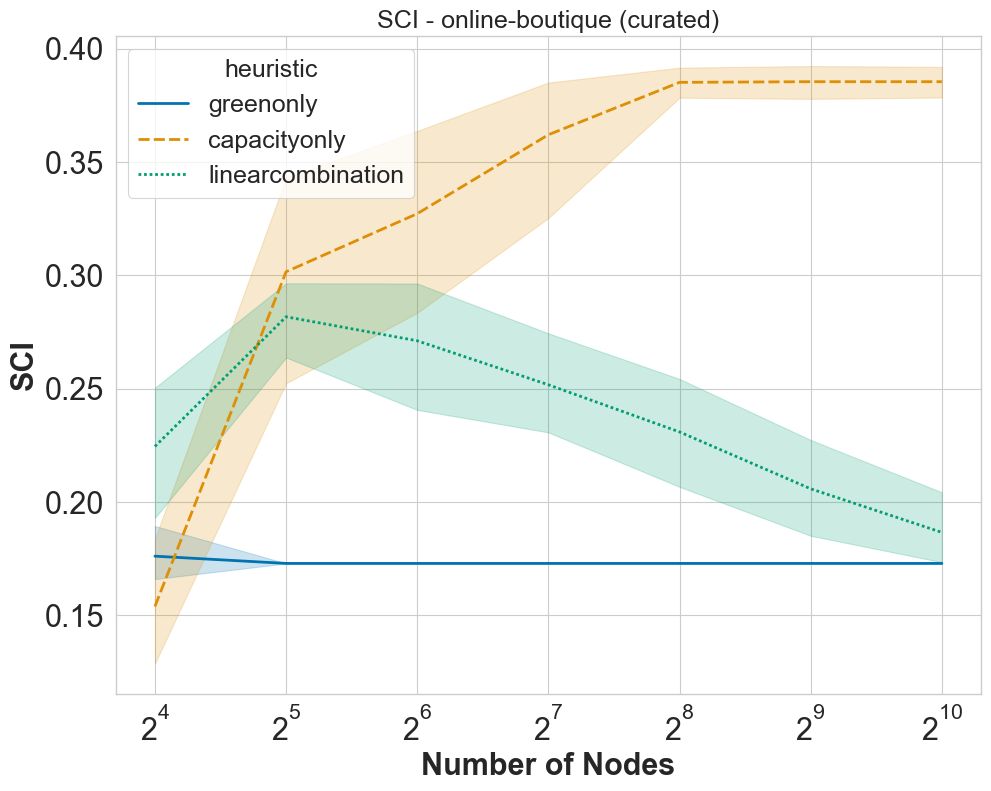

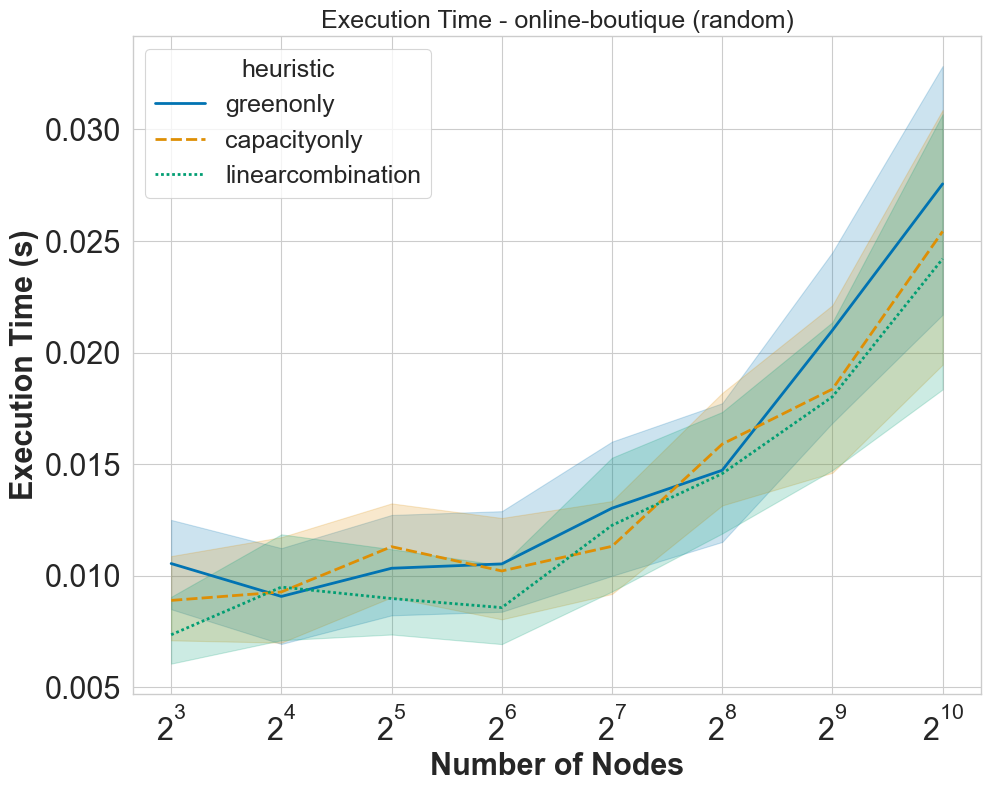

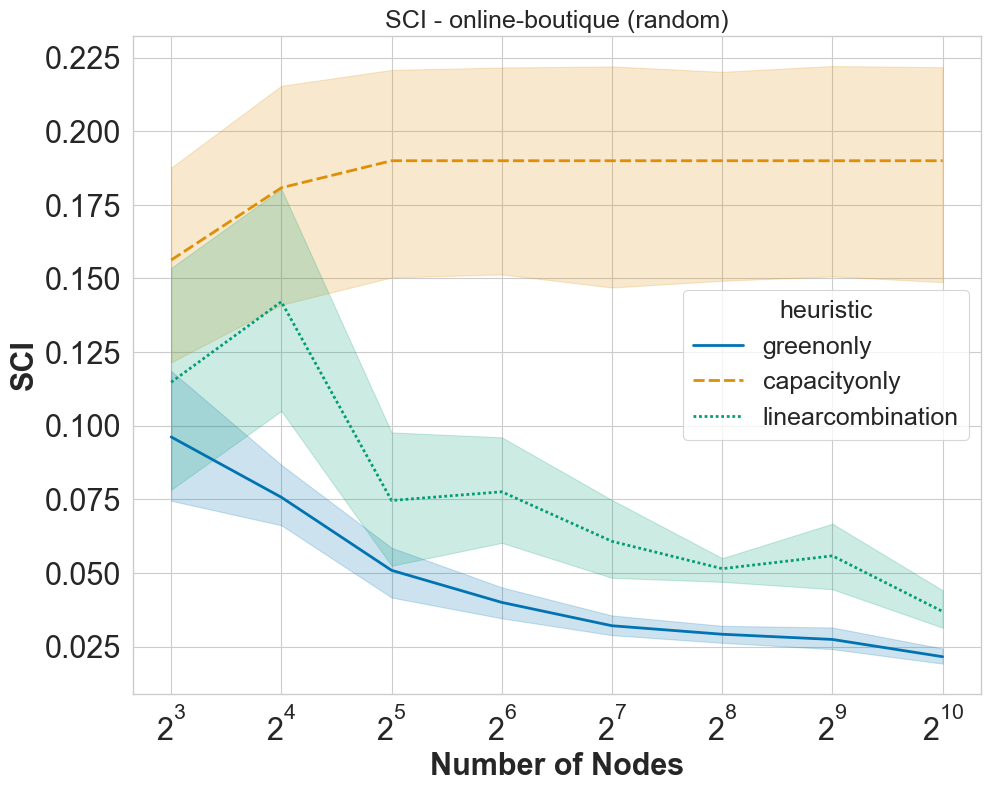

In [7]:
for application in APPLICATIONS:
    plot_relative_sci_distance(df[df["success"] == True], application)
    for mode in MODES:
        plot_execution_time(df_success, application, mode)
        plot_sci(df_success, application, mode)